# Modelamiento: arquitecturas de deep learning y comparación final

Este notebook entrena las tres arquitecturas de deep learning seleccionadas para el
proyecto (MLP superficial, MLP profunda y MLP residual) en PyTorch, las compara contra
los tres modelos de ML ya elegidos en `04_balanceo_modelos.ipynb` (cada uno con su
propia estrategia de balanceo) y evalúa el modelo final sobre el conjunto de prueba,
usado una única vez.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

Dispositivo: cpu


## 1. Carga de artefactos preprocesados

Las redes requieren arrays densos, por lo que las matrices dispersas del preprocesador se convierten con `.toarray()`. El dataset es pequeño (7.000 x 58), por lo que esto no representa un problema de memoria.

In [2]:
ruta_artefactos = Path("../artifacts")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")

X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = artefactos["y_train"].to_numpy().astype("float32")
y_val = artefactos["y_val"].to_numpy().astype("float32")
y_test = artefactos["y_test"].to_numpy().astype("float32")
pesos_clase = artefactos["pesos_clase"]

def a_denso(matriz):
    return matriz.toarray().astype("float32") if hasattr(matriz, "toarray") else matriz.astype("float32")

X_train_denso = a_denso(X_train)
X_val_denso = a_denso(X_val)
X_test_denso = a_denso(X_test)

n_variables = X_train_denso.shape[1]

print("X_train:", X_train_denso.shape)
print("X_val:", X_val_denso.shape)
print("X_test:", X_test_denso.shape)

X_train: (7000, 58)
X_val: (1500, 58)
X_test: (1500, 58)


## 2. Preparación de DataLoaders

Se usa un `DataLoader` con lotes de 256 observaciones para el entrenamiento, y
generadores con semilla fija para reproducibilidad del orden de los lotes.

In [3]:
generador = torch.Generator().manual_seed(RANDOM_STATE)

train_dataset = TensorDataset(
    torch.from_numpy(X_train_denso),
    torch.from_numpy(y_train),
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val_denso),
    torch.from_numpy(y_val),
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=generador)

X_val_tensor = torch.from_numpy(X_val_denso).to(DEVICE)
X_test_tensor = torch.from_numpy(X_test_denso).to(DEVICE)

## 3. Arquitecturas

- **MLP superficial (58-64-1):** una capa oculta de 64 neuronas, ReLU y dropout.
- **MLP profunda (58-128-64-32-1):** tres capas ocultas con normalización por lotes
  (`BatchNorm1d`) y dropout, orientada a interacciones jerárquicas.
- **MLP residual:** proyección inicial a 64 dimensiones seguida de dos bloques
  residuales con conexión de salto, inspirada en baselines tipo ResNet para datos
  tabulares.

In [4]:
class MLPSuperficial(nn.Module):
    def __init__(self, n_entradas):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_entradas, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.red(x).squeeze(-1)


class MLPProfunda(nn.Module):
    def __init__(self, n_entradas):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_entradas, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.red(x).squeeze(-1)


class BloqueResidual(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.capa1 = nn.Linear(dimension, dimension)
        self.norma1 = nn.BatchNorm1d(dimension)
        self.capa2 = nn.Linear(dimension, dimension)
        self.norma2 = nn.BatchNorm1d(dimension)
        self.activacion = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        residual = x
        salida = self.activacion(self.norma1(self.capa1(x)))
        salida = self.dropout(salida)
        salida = self.norma2(self.capa2(salida))
        return self.activacion(salida + residual)


class MLPResidual(nn.Module):
    def __init__(self, n_entradas):
        super().__init__()
        self.proyeccion = nn.Sequential(
            nn.Linear(n_entradas, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.bloque1 = BloqueResidual(64)
        self.bloque2 = BloqueResidual(64)
        self.salida = nn.Linear(64, 1)

    def forward(self, x):
        x = self.proyeccion(x)
        x = self.bloque1(x)
        x = self.bloque2(x)
        return self.salida(x).squeeze(-1)

## 4. Función de entrenamiento con early stopping

Se entrena con `AdamW` y `BCEWithLogitsLoss` ponderada mediante `pos_weight` (igual a
la relación de desbalance del conjunto de entrenamiento), hasta un máximo de 30 épocas,
deteniendo el entrenamiento si el ROC-AUC de validación no mejora durante 5 épocas
consecutivas y recuperando los pesos de la mejor época.

In [5]:
def entrenar_modelo(modelo, nombre, paciencia=5, max_epocas=30):
    modelo.to(DEVICE)

    relacion_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
    pos_weight = torch.tensor([relacion_desbalance], dtype=torch.float32, device=DEVICE)
    funcion_perdida = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizador = torch.optim.AdamW(modelo.parameters(), lr=1e-3)

    mejor_roc_auc = -np.inf
    mejor_estado = None
    epocas_sin_mejora = 0
    historial = []

    for epoca in range(1, max_epocas + 1):
        modelo.train()
        perdida_acumulada = 0.0

        for lote_X, lote_y in train_loader:
            lote_X, lote_y = lote_X.to(DEVICE), lote_y.to(DEVICE)

            optimizador.zero_grad()
            logits = modelo(lote_X)
            perdida = funcion_perdida(logits, lote_y)
            perdida.backward()
            optimizador.step()

            perdida_acumulada += perdida.item() * lote_X.size(0)

        perdida_promedio = perdida_acumulada / len(train_loader.dataset)

        modelo.eval()
        with torch.no_grad():
            logits_val = modelo(X_val_tensor)
            proba_val = torch.sigmoid(logits_val).cpu().numpy()

        roc_auc_val = roc_auc_score(y_val, proba_val)
        historial.append({"epoca": epoca, "perdida_entrenamiento": perdida_promedio, "roc_auc_val": roc_auc_val})

        if roc_auc_val > mejor_roc_auc:
            mejor_roc_auc = roc_auc_val
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if epocas_sin_mejora >= paciencia:
            print(f"[{nombre}] early stopping en época {epoca} (mejor ROC-AUC val: {mejor_roc_auc:.4f})")
            break

    modelo.load_state_dict(mejor_estado)
    print(f"[{nombre}] entrenamiento finalizado - mejor ROC-AUC val: {mejor_roc_auc:.4f} en {len(historial)} épocas")

    return modelo, pd.DataFrame(historial)

## 5. Entrenamiento de las tres arquitecturas

In [6]:
torch.manual_seed(RANDOM_STATE)
modelo_superficial, historial_superficial = entrenar_modelo(MLPSuperficial(n_variables), "MLP superficial")

[MLP superficial] entrenamiento finalizado - mejor ROC-AUC val: 0.7634 en 30 épocas


In [7]:
torch.manual_seed(RANDOM_STATE)
modelo_profunda, historial_profunda = entrenar_modelo(MLPProfunda(n_variables), "MLP profunda")

[MLP profunda] early stopping en época 17 (mejor ROC-AUC val: 0.7716)
[MLP profunda] entrenamiento finalizado - mejor ROC-AUC val: 0.7716 en 17 épocas


In [8]:
torch.manual_seed(RANDOM_STATE)
modelo_residual, historial_residual = entrenar_modelo(MLPResidual(n_variables), "MLP residual")

[MLP residual] early stopping en época 13 (mejor ROC-AUC val: 0.7626)
[MLP residual] entrenamiento finalizado - mejor ROC-AUC val: 0.7626 en 13 épocas


## 6. Curvas de entrenamiento (ROC-AUC de validación por época)

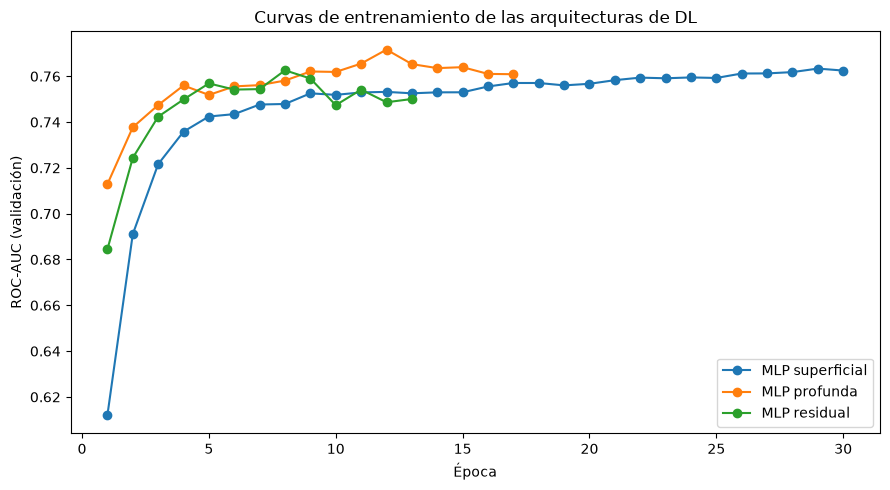

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for nombre, historial in [
    ("MLP superficial", historial_superficial),
    ("MLP profunda", historial_profunda),
    ("MLP residual", historial_residual),
]:
    ax.plot(historial["epoca"], historial["roc_auc_val"], marker="o", label=nombre)

ax.set_xlabel("Época")
ax.set_ylabel("ROC-AUC (validación)")
ax.set_title("Curvas de entrenamiento de las arquitecturas de DL")
ax.legend()
plt.tight_layout()

ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)
plt.savefig(ruta_figuras / "10_01_curvas_entrenamiento_dl.png", dpi=150)
plt.show()

In [10]:
def epoca_optima(historial):
    fila_mejor = historial.loc[historial["roc_auc_val"].idxmax()]
    return int(fila_mejor["epoca"]), fila_mejor["roc_auc_val"]

for nombre, historial in [
    ("MLP superficial", historial_superficial),
    ("MLP profunda", historial_profunda),
    ("MLP residual", historial_residual),
]:
    epoca, roc_auc = epoca_optima(historial)
    print(f"{nombre}: mejor época = {epoca} de {len(historial)} entrenadas (ROC-AUC val = {roc_auc:.4f})")

MLP superficial: mejor época = 29 de 30 entrenadas (ROC-AUC val = 0.7634)
MLP profunda: mejor época = 12 de 17 entrenadas (ROC-AUC val = 0.7716)
MLP residual: mejor época = 8 de 13 entrenadas (ROC-AUC val = 0.7626)


## 7. Evaluación de las redes en validación

Se usa el mismo conjunto de métricas que en los notebooks anteriores, con umbral 0,5
sobre la probabilidad (`sigmoid` del logit).

In [11]:
def evaluar_red(modelo, nombre, X_tensor, y_true):
    modelo.eval()
    with torch.no_grad():
        logits = modelo(X_tensor)
        proba = torch.sigmoid(logits).cpu().numpy()

    prediccion = (proba >= 0.5).astype(int)

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, prediccion),
        "precision": precision_score(y_true, prediccion, zero_division=0),
        "recall": recall_score(y_true, prediccion, zero_division=0),
        "f1": f1_score(y_true, prediccion, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }


resultados_dl = [
    evaluar_red(modelo_superficial, "MLP superficial", X_val_tensor, y_val),
    evaluar_red(modelo_profunda, "MLP profunda", X_val_tensor, y_val),
    evaluar_red(modelo_residual, "MLP residual", X_val_tensor, y_val),
]

tabla_dl = pd.DataFrame(resultados_dl).set_index("modelo")
tabla_dl.round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
MLP superficial,0.728,0.216,0.634,0.322,0.763,0.237
MLP profunda,0.683,0.208,0.752,0.326,0.772,0.252
MLP residual,0.722,0.218,0.667,0.329,0.763,0.237


## 8. Comparación final: 3 modelos de ML + 3 arquitecturas de DL (validación)

Se cargan los resultados de validación de los modelos de ML ya seleccionados en
`04_balanceo_modelos.ipynb` (cada uno con su propia estrategia de balanceo elegida) y
se combinan con los resultados de las redes para construir la tabla comparativa final,
equivalente a la Tabla 8 del informe.

In [12]:
ruta_modelos = Path("../models")

eleccion_ml = pd.read_csv(ruta_modelos / "eleccion_balanceo_por_modelo.csv", index_col="modelo")

nombres_ml = {
    "Regresión logística": "Regresión logística + ROS",
    "Random Forest": "Random Forest + ROS",
    "XGBoost": "XGBoost + ROS",
}

tabla_ml = eleccion_ml[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].copy()
tabla_ml.index = [nombres_ml[nombre] for nombre in tabla_ml.index]

tabla_comparativa_sin_redondear = pd.concat([tabla_ml, tabla_dl])

# Nota: tabla_ml llega con precisión de 3 decimales porque así quedó persistida
# en 04_balanceo_modelos.ipynb (eleccion_balanceo_por_modelo.csv). tabla_dl sí
# conserva la precisión completa calculada en este notebook. El margen de
# selección usado más abajo (0,01) es de todas formas mucho más ancho que esa
# resolución, por lo que no afecta la decisión.
tabla_comparativa_final = tabla_comparativa_sin_redondear.round(3)
tabla_comparativa_final

,accuracy,precision,recall,f1,roc_auc,pr_auc
Regresión logística + ROS,0.705,0.215,0.712,0.330,0.751,0.221
Random Forest + ROS,0.776,0.278,0.752,0.406,0.818,0.302
XGBoost + ROS,0.737,0.259,0.843,0.396,0.826,0.333
MLP superficial,0.728,0.216,0.634,0.322,0.763,0.237
MLP profunda,0.683,0.208,0.752,0.326,0.772,0.252
MLP residual,0.722,0.218,0.667,0.329,0.763,0.237


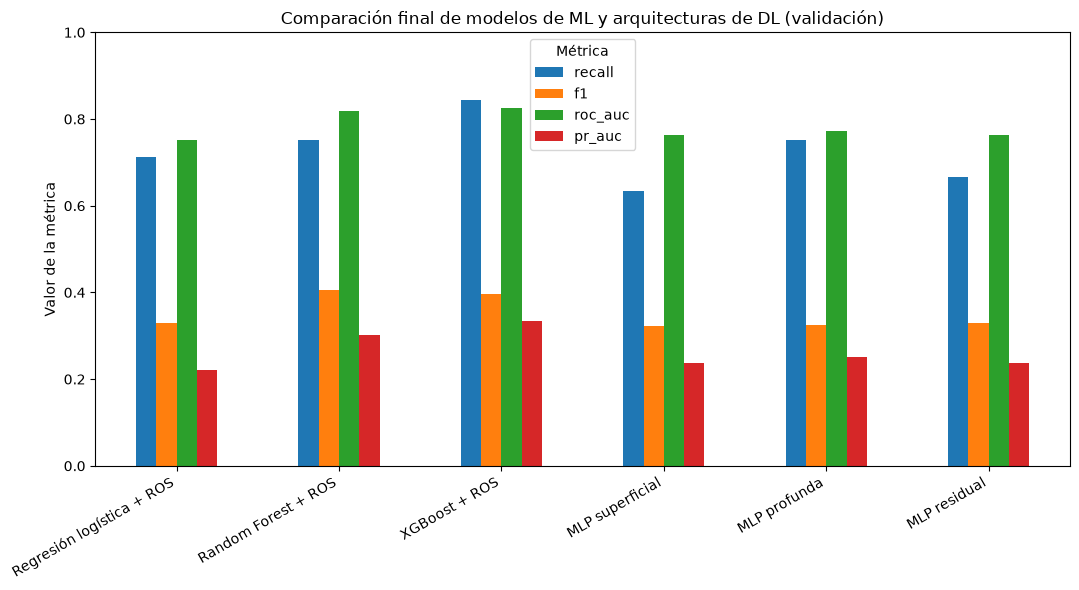

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

metricas_a_graficar = ["recall", "f1", "roc_auc", "pr_auc"]
tabla_comparativa_final[metricas_a_graficar].plot(kind="bar", ax=ax)

ax.set_title("Comparación final de modelos de ML y arquitecturas de DL (validación)")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(title="Métrica")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ruta_figuras / "10_02_comparacion_final_ml_dl.png", dpi=150)
plt.show()

## 9. Selección del modelo final y evaluación en el conjunto de prueba

Se aplica el mismo criterio usado en `04_balanceo_modelos.ipynb`: se elige el modelo con **mayor F1**; si otro candidato queda dentro de un margen de F1 menor o igual a 0,01 respecto del mejor, se prioriza entre esos candidatos el de **mayor recall**, dado que es el criterio de negocio declarado en la sección 5.3 del informe. El modelo elegido se evalúa **una única vez** sobre el conjunto de prueba, reservado hasta este punto.

In [14]:
print("Modelo con mayor recall en validación:")
print(tabla_comparativa_sin_redondear["recall"].idxmax(), "-", tabla_comparativa_sin_redondear["recall"].max())

print("\nModelo con mayor ROC-AUC en validación:")
print(tabla_comparativa_sin_redondear["roc_auc"].idxmax(), "-", tabla_comparativa_sin_redondear["roc_auc"].max())

print("\nModelo con mayor F1 en validación:")
print(tabla_comparativa_sin_redondear["f1"].idxmax(), "-", tabla_comparativa_sin_redondear["f1"].max())

Modelo con mayor recall en validación:
XGBoost + ROS - 0.843

Modelo con mayor ROC-AUC en validación:
XGBoost + ROS - 0.826

Modelo con mayor F1 en validación:
Random Forest + ROS - 0.406


La selección no se fija de antemano: el código de la siguiente celda aplica el criterio descrito arriba (mejor F1, con desempate por recall dentro de un margen de 0,01) sobre `tabla_comparativa_sin_redondear`, e imprime qué candidatos entraron en el margen y cuál fue finalmente elegido.

In [15]:
margen_f1 = 0.01
mejor_f1 = tabla_comparativa_sin_redondear["f1"].max()

candidatos = tabla_comparativa_sin_redondear[
    (mejor_f1 - tabla_comparativa_sin_redondear["f1"])
    <= margen_f1 + 1e-12
]

nombre_modelo_final = candidatos["recall"].idxmax()

print("Candidatos con F1 dentro del margen definido:")
display(candidatos.round(3))

print(f"\nModelo final seleccionado: {nombre_modelo_final}")

archivos_modelos_ml = {
    "Regresión logística + ROS": "logistic_regression_final.joblib",
    "Random Forest + ROS": "random_forest_final.joblib",
    "XGBoost + ROS": "xgboost_final.joblib",
}
redes_dl = {
    "MLP superficial": modelo_superficial,
    "MLP profunda": modelo_profunda,
    "MLP residual": modelo_residual,
}

if nombre_modelo_final in archivos_modelos_ml:
    modelo_final = joblib.load(ruta_modelos / archivos_modelos_ml[nombre_modelo_final])

    y_pred_test = modelo_final.predict(X_test)
    y_proba_test = modelo_final.predict_proba(X_test)[:, 1]
else:
    modelo_final = redes_dl[nombre_modelo_final]
    modelo_final.eval()
    with torch.no_grad():
        logits_test = modelo_final(X_test_tensor)
        y_proba_test = torch.sigmoid(logits_test).cpu().numpy()
    y_pred_test = (y_proba_test >= 0.5).astype(int)

metricas_test = {
    "accuracy": accuracy_score(y_test, y_pred_test),
    "precision": precision_score(y_test, y_pred_test, zero_division=0),
    "recall": recall_score(y_test, y_pred_test, zero_division=0),
    "f1": f1_score(y_test, y_pred_test, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_test),
    "pr_auc": average_precision_score(y_test, y_proba_test),
}

print(f"\nMétricas de {nombre_modelo_final} en el conjunto de prueba:")
metricas_test

Candidatos con F1 dentro del margen definido:


,accuracy,precision,recall,f1,roc_auc,pr_auc
Random Forest + ROS,0.776,0.278,0.752,0.406,0.818,0.302
XGBoost + ROS,0.737,0.259,0.843,0.396,0.826,0.333



Modelo final seleccionado: XGBoost + ROS

Métricas de XGBoost + ROS en el conjunto de prueba:


{'accuracy': 0.7186666666666667,
 'precision': 0.2315369261477046,
 'recall': 0.7581699346405228,
 'f1': 0.3547400611620795,
 'roc_auc': 0.7806551474833933,
 'pr_auc': 0.30026234474403984}

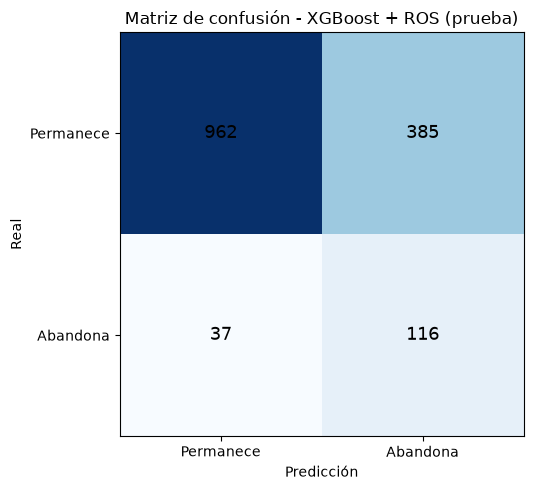

array([[962, 385],
       [ 37, 116]])

In [16]:
matriz_test = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(matriz_test, cmap="Blues")
ax.set_title(f"Matriz de confusión - {nombre_modelo_final} (prueba)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Permanece", "Abandona"])
ax.set_yticklabels(["Permanece", "Abandona"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_test[i, j], ha="center", va="center", fontsize=13)

plt.tight_layout()
plt.savefig(ruta_figuras / "10_03_matriz_confusion_test.png", dpi=150)
plt.show()

matriz_test

## 10. Guardado de resultados finales

In [17]:
tabla_comparativa_final.to_csv(ruta_modelos / "comparacion_final_ml_dl_validacion.csv")

pd.Series(metricas_test).round(3).to_csv(ruta_modelos / "metricas_test_modelo_final.csv")

torch.save(modelo_superficial.state_dict(), ruta_modelos / "mlp_superficial.pt")
torch.save(modelo_profunda.state_dict(), ruta_modelos / "mlp_profunda.pt")
torch.save(modelo_residual.state_dict(), ruta_modelos / "mlp_residual.pt")

print("Resultados y modelos guardados en:", ruta_modelos.resolve())

Resultados y modelos guardados en: C:\Users\Usuario\OneDrive\Documentos\UNAB\2026\Machine Learning\Proyecto\acif104-churn-grupo3\models


## 11. Conclusiones

En este trabajo se compararon distintos modelos de machine learning y redes neuronales para predecir qué clientes presentan riesgo de abandono. También se evaluaron diferentes estrategias de balanceo, ya que los clientes con churn representan una proporción menor del conjunto de datos.

Durante el entrenamiento, las redes más complejas activaron la detención temprana, lo que permitió conservar la versión con mejor desempeño en validación y reducir el riesgo de sobreajuste.

En prueba, el desempeño fue menor que en validación, especialmente en recall, que disminuyó de 0,843 a 0,758. Esto evidencia la dificultad de mantener el mismo rendimiento al trabajar con datos completamente nuevos.

Los resultados muestran que las redes neuronales no superaron a los principales modelos de machine learning. Random Forest obtuvo la mayor precisión y el mejor F1, mientras que XGBoost con RandomOverSampler (ROS) alcanzó la mayor capacidad para detectar clientes que podrían abandonar.

Se seleccionó **XGBoost + ROS** como modelo final. Aunque Random Forest obtuvo un F1 levemente superior, la diferencia fue pequeña. En cambio, XGBoost alcanzó un recall considerablemente mayor, además de mejores resultados en ROC-AUC y PR-AUC. Esta elección responde al objetivo del proyecto, ya que se considera más importante detectar oportunamente a un cliente en riesgo que evitar completamente las falsas alarmas.

En el conjunto de prueba, el modelo detectó correctamente a **116 de los 153 clientes que abandonaron**, alcanzando un recall de **0,758**. Esto significa que logró identificar aproximadamente tres de cada cuatro abandonos reales. Sin embargo, su precisión fue de **0,232**, por lo que también generó una cantidad importante de falsas alarmas.

En conclusión, el modelo permite identificar patrones útiles para anticipar el churn, pero sus predicciones no deberían utilizarse como una decisión definitiva. Su principal utilidad sería apoyar la priorización de clientes para acciones de retención, como comunicaciones personalizadas, beneficios o recomendaciones. Como trabajo futuro, se podrían ajustar los hiperparámetros y el umbral de clasificación para buscar un mejor equilibrio entre detectar abandonos y reducir las falsas alertas.